<a href="https://colab.research.google.com/github/CienciaDatosUdea/005_CCA_Estudiantes/blob/main/Laboratorios/07_cLab_TcEstudiante.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Laboratorio — Determinación de la temperatura crítica del modelo de Ising 2D con redes neuronales de *scikit-learn*

**Maestría en Computación Científica · Módulo de Redes Neuronales · Modelo de Ising 2D**

En este laboratorio vas a **entrenar una red neuronal clasificadora con `scikit-learn`** y a
usarla como un *termómetro* para localizar la **temperatura crítica** $T_c$ de la transición
de fase ferromagnética del modelo de Ising en 2D.



## Objetivos de aprendizaje

Al terminar este laboratorio serás capaz de:

1. Entrenar un clasificador de red neuronal con `sklearn.neural_network.MLPClassifier`,
   identificando el papel de cada hiperparámetro.
2. **Contrastar la API de `scikit-learn` 
3. Usar un clasificador entrenado **lejos** de la transición para estimar la fase
   (ordenada / desordenada) a temperaturas **cercanas** a $T_c$.
4. Estimar $T_c$ a partir del cruce $\langle P(y{=}1\mid X)\rangle = 0.5$, cuantificar su
   incertidumbre entre realizaciones y compararla con el valor exacto de Onsager.

## 1. Física: transición de fase del modelo de Ising 2D

El modelo de Ising 2D en una red $L\times L$ con acoplamiento ferromagnético $J>0$ tiene energía

$$E(\{s\}) = -J \sum_{\langle i,j\rangle} s_i\, s_j, \qquad s_i \in \{-1, +1\},$$

donde la suma es sobre pares de primeros vecinos. En unidades $J = k_B = 1$, el sistema infinito
presenta una transición de fase de segundo orden a la **temperatura crítica de Onsager**

$$T_c = \frac{2}{\ln\!\left(1+\sqrt{2}\right)} \approx 2.269.$$

- $T < T_c$: **fase ordenada** (ferromagnética), magnetización por sitio $|m|$ grande.
- $T > T_c$: **fase desordenada** (paramagnética), $|m|\approx 0$.

**Idea del laboratorio** (Carrasquilla & Melko, *Nature Physics* **13**, 431 (2017)): un
clasificador entrenado solo con configuraciones *claramente* ordenadas ($y=0$) y *claramente*
desordenadas ($y=1$) aprende una frontera de decisión que, evaluada en configuraciones cercanas
a $T_c$, se comporta como un **parámetro de orden efectivo**. La temperatura donde
$\langle P(y{=}1\mid X)\rangle = 0.5$ estima $T_c$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier

RNG = 42 # Random number generator. Con la semilla fija todo el proceso "aleatorio" se vuelve determinista. Esto se hace para que los resultados sean reproducibles. 
np.random.seed(RNG)

## 3. Datos: configuraciones lejos de $T_c$

`ising_dataset.npz` contiene configuraciones de espines de una red $16\times 16$ con frontera
periódica, generadas por Monte Carlo (Metrópolis). Campos:

| Campo | Forma | Significado |
|---|---|---|
| `X` | `(1600, 16, 16)` | Configuraciones de espines $s_i \in \{-1,+1\}$ |
| `y` | `(1600,)` | Etiqueta de fase: `0` = ordenada ($T$ baja), `1` = desordenada ($T$ alta) |
| `T` | `(1600,)` | Temperatura de cada configuración |
| `m` | `(1600,)` | Magnetización por sitio $|m|$ |
| `realizacion` | `(1600,)` | Índice de cadena Monte Carlo independiente (`0..3`) |
| `Tc`, `L`, `frontera` | escalares | Metadatos ($T_c$ exacto, tamaño, tipo de frontera) |

Las temperaturas de entrenamiento **evitan** la región crítica: hay un hueco entre
$T=1.9$ y $T=2.6$.

In [2]:
datos = np.load("Datos/ising_dataset.npz", allow_pickle=False)
X = datos["X"]
y = datos["y"]
T = datos["T"]
m = datos["m"]
realizacion = datos["realizacion"]

Tc_exacto = float(datos["Tc"])
L = int(datos["L"])

print("X:", X.shape, X.dtype)
print("y:", y.shape, "->", np.unique(y, return_counts=True))
print("realizaciones:", np.unique(realizacion))
print("Tc exacto (Onsager):", Tc_exacto)
#print(realizacion)

X: (1600, 16, 16) int8
y: (1600,) -> (array([0, 1], dtype=int8), array([800, 800]))
realizaciones: [0 1 2 3]
Tc exacto (Onsager): 2.269185314213022


### Ejercicio 1 — Exploración

Responde con código y en una celda de texto:

1. ¿Qué temperaturas tienen etiqueta `y = 0` y cuáles `y = 1`? ¿Dónde está el "hueco"?
2. ¿Está balanceado el problema (cuántas configuraciones por clase)?
3. Grafica el histograma de $|m|$ separando por clase. ¿Se separan bien las dos fases?

Número de configuraciones con y=0: 800
Número de configuraciones con y=1: 800


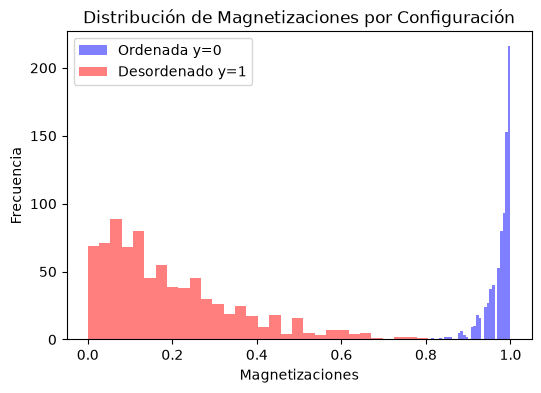

In [3]:
# --- Ejercicio 1  ---
T_0 = [] # Temperaturas con configuración 0
T_1 = [] # Temperaturas con configuración 1
m_0 = [] # Magnetizaciones con configuración 0
m_1 = [] # Magnetizaciones con configuración 1

for i in range(len(y)):
    if y[i]==0:
        T_0.append(T[i])
        m_0.append(m[i])
    else:
        T_1.append(T[i])
        m_1.append(m[i])
    
        
print(f"Número de configuraciones con y=0: {len(T_0)}")
print(f"Número de configuraciones con y=1: {len(T_1)}")

plt.figure(figsize=(6, 4))
plt.hist(m_0, bins=30, alpha=0.5, label='Ordenada y=0', color='blue')
plt.hist(m_1, bins=30, alpha=0.5, label='Desordenado y=1', color='red')
plt.xlabel('Magnetizaciones')
plt.ylabel('Frecuencia')
plt.title('Distribución de Magnetizaciones por Configuración')
plt.legend()
plt.show()


Ambas fases se logran separar bien.
La fase ordenada muestra poca variabilidad de imagen a imagen, casi todas sus 800 configuraciones tienen |m| muy cerca de 1. 
La fase desordenada,en cambio, muestra mucha más variabilidad entre imágenes (valores de |m| que van desde casi 0 hasta ~0.7), lo que indica que, dentro de cada imagen individual de esa fase, todavía persisten correlaciones espaciales de corto alcance entre
espines vecinos (dominios) más marcadas en las temperaturas de esa clase más cercanas a $T_c$.

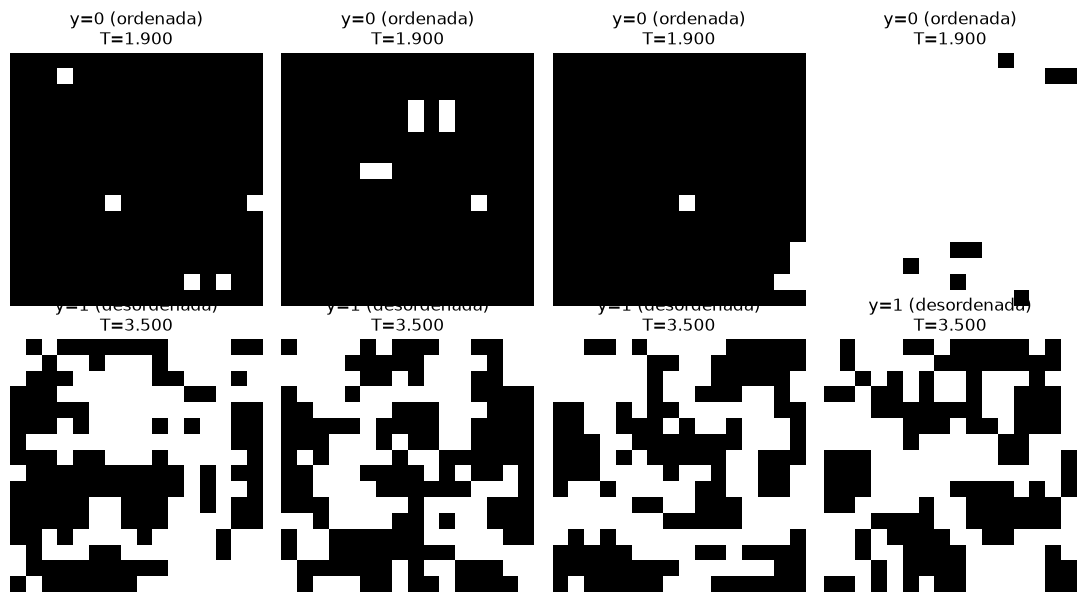

In [4]:
# Configuraciones típicas a T baja y T alta
fig, axes = plt.subplots(2, 4, figsize=(11, 6))
for row, (cls, titulo) in enumerate([(0, "ordenada"), (1, "desordenada")]):
    idx = np.where(y == cls)[0][:4]
    for k, i in enumerate(idx):
        axes[row, k].imshow(X[i], cmap="gray", vmin=-1, vmax=1)
        axes[row, k].set_title(f"y={cls} ({titulo})\nT={T[i]:.3f}")
        axes[row, k].axis("off")
plt.tight_layout()
plt.show()

## 4. Partición de los datos: por **realización**

Las configuraciones de una misma cadena Monte Carlo (`realizacion`) están **correlacionadas**
temporalmente. Si mezcláramos al azar, configuraciones casi idénticas caerían en *train* y en
*test* a la vez → fuga de información y métricas infladas.

Partimos por realización:

- **Entrenamiento:** realizaciones `0` y `1`
- **Validación:** realización `2`
- **Prueba:** realización `3`

Además aplanamos cada configuración $16\times16 \to 256$ porque `MLPClassifier` espera
vectores de características.

### Ejercicio 2 — Construir los conjuntos

Completa las máscaras y los arreglos aplanados. Deberías obtener
`X_train (800, 256)`, `X_val (400, 256)` y `X_test (400, 256)`.

In [5]:
# --- Ejercicio 2  ---
mask_train = np.isin(realizacion, [0, 1]) # Arreglo de booleanos que indica si la realización es 0 o 1 (entrenamiento)
mask_val   = realizacion == 2 # Arreglo de booleanos que indica si la realización es 2 (validación)
mask_test  = realizacion == 3 # Arreglo de booleanos que indica si la realización es 3 (prueba)



def aplanar(A):
    return A.reshape(A.shape[0], L * L) # Devuelve un arreglo 2D: 800 filas 256 columna


print(X[mask_train].shape)
print(X[mask_val].shape)
print(X[mask_test].shape)

# Aplanar configuraciones
X_train = aplanar(X[mask_train])# Arreglo 2D de las configuraciones obtenidas con la realizacion 0 y 1    
X_val = aplanar(X[mask_val])    # Arreglo 2D de las configuraciones obtenidas con la realizacion 2    
X_test = aplanar(X[mask_test])  # Arreglo 2D de las configuraciones obtenidas con la realizacion 3    

# Obtener lista de etiquetas 
y_train = y[mask_train]         # Arreglo de 1 y 0 de las configuraciones obtenidas con la realizacion 0 y 1
y_val   = y[mask_val]           # Arreglo de 1 y 0 de las configuraciones obtenidas con la realizacion 2
y_test  = y[mask_test]          # Arreglo de 1 y 0 de las configuraciones obtenidas con la realizacion 3

# Obtener lista de Temperaturas 
T_train = T[mask_train]         # Arreglo de temperaturas de las configuraciones obtenidas con la realización 0 y 1
T_val   = T[mask_val]           # Arreglo de temperaturas de las configuraciones obtenidas con la realización 2
T_test  = T[mask_test]          # Arreglo de temperaturas de las configuraciones obtenidas con la realización 3


for nombre, Xs, ys in [("train", X_train, y_train),
                       ("val",   X_val,   y_val),
                       ("test",  X_test,  y_test)]:
    print(f"{nombre:5s}  X={Xs.shape}  y={ys.shape}  clases={np.bincount(ys)}")

(800, 16, 16)
(400, 16, 16)
(400, 16, 16)
train  X=(800, 256)  y=(800,)  clases=[400 400]
val    X=(400, 256)  y=(400,)  clases=[200 200]
test   X=(400, 256)  y=(400,)  clases=[200 200]


## 5. Entrenar el `MLPClassifier`

| Argumento | Valor | Qué controla |
|---|---|---|
| `hidden_layer_sizes=(16, 8, 4)` | 3 capas ocultas | Arquitectura: 256 → 16 → 8 → 4 → 2 |
| `activation="relu"` | ReLU | No linealidad de las capas ocultas |
| `solver="adam"` | Adam | Optimizador basado en gradiente estocástico |
| `learning_rate_init=0.001` | 0.001 | Tamaño de paso inicial |
| `max_iter=1000` | 1000 | Máximo de épocas (puede parar antes por tolerancia) |
| `random_state=42` | 42 | Reproducibilidad (init de pesos y *shuffling*) |

> La capa de salida (2 neuronas, *softmax*) y la pérdida (*log-loss*) las añade `scikit-learn`
> automáticamente al ver que `y` tiene dos clases enteras. En `NN_Cero.ipynb` esto era la
> `sigmoide` final + `cost_Function`; en PyTorch era `nn.Linear(..., 1)` + `BCEWithLogitsLoss`.

### Ejercicio 3 — Instanciar, entrenar y evaluar

1. Crea el modelo con los hiperparámetros de la tabla y ajústalo con `X_train, y_train`.
2. Reporta *accuracy* en train / val / test con `.score(...)`.
3. Grafica `model.loss_curve_` (la pérdida por época que `scikit-learn` guarda).

iteraciones: 675   log-loss final: 0.0453
accuracy train: 1.0000
accuracy val  : 0.9850
accuracy test : 0.9875


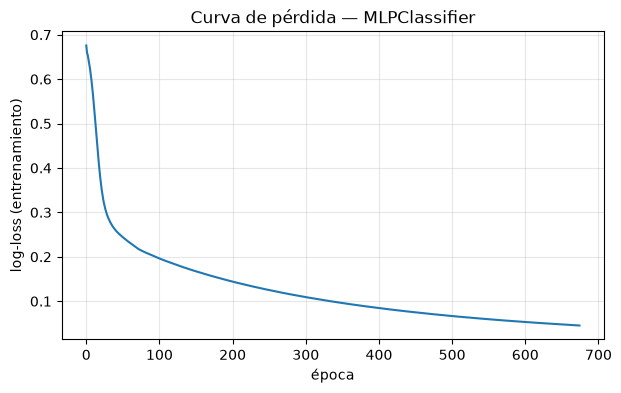

In [6]:
# --- Ejercicio 3  ---

# Creación del modelo
model = MLPClassifier(
    hidden_layer_sizes=(16, 8, 4),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=RNG,
)
# Acá se entrena el modelo.fit es el método que todo modelo usa. Recibe los datos de entrada (X_train, forma (800, 256)) y las etiquetas correspondientes (y_train, forma (800,)), y por dentro ejecuta todo el proceso
model.fit(X_train, y_train)

# Se usa el modelo ya entrenado para predecir la clase de cada imágen de X. Esto se hace para cada conjunto de imágenes: train, val, test.
acc = {
    "train": model.score(X_train, y_train),     
    "val":   model.score(X_val,   y_val),
    "test":  model.score(X_test,  y_test),
}
print(f"iteraciones: {model.n_iter_}   log-loss final: {model.loss_:.4f}")
for k, v in acc.items():
    print(f"accuracy {k:5s}: {v:.4f}")
    
#print( list(acc.items())[0] )
#print( list(acc.items())[1] )
#print( list(acc.items())[2] )

plt.figure(figsize=(7, 4))
plt.plot(model.loss_curve_)
plt.xlabel("época")
plt.ylabel("log-loss (entrenamiento)")
plt.title("Curva de pérdida — MLPClassifier")
plt.grid(alpha=0.3)
plt.show()

Se observa como el modelo va aprendiendo época por época durante las 675 iteraciones que corrió antes de detenerse.
- Alrededor de las primeras épocas, el log-loss es ≈0.693, lo que indica que el modelo no sabe nada.
- Alrededor de las época 0-50, el log-loss es ≈0.693 - 0.3, lo que indica que el modelo aprende lo obvio y fácil de captar.
- Alrededor de las épocas 50 - 600, el log-loss sigue bajando pero cada vez más despacio.
- Por encima de 600 épocas, el modelo decide detener el entrenamiento antes de las 1000 épocas máximas. El algoritmo concluye que   seguir entrenando ya no es necesario dado que alcanzó un nivel de confianza con respecto a la probabilidad de clasificar bien.

### Reflexión (sección 5)

- El *accuracy* de entrenamiento suele ser `1.0000`. ¿Es esto sobreajuste preocupante, dado que
  train / val / test dan valores parecidos? ¿Por qué este problema es "fácil" **lejos** de $T_c$?
- ¿Qué esperas que ocurra con las probabilidades del modelo **cerca** de $T_c$, donde no vio datos?

1. Un modelo sobreajustado es uno que memorizó los datos de entrenamiento (accuracy muy alto) y tiene un mal resultado con los datos que no conoció (accuracy bajo). Si hay una diferencia significativa entre estos dos indicativos, entoonces se tiene un sobreajuste.
En nuestro caso:



In [7]:
print(f"Diferencia entre accuracy train y val {list(acc.values())[0] - list(acc.values())[1]} ")
print(f"Diferencia entre accuracy train y test {list(acc.values())[0] - list(acc.values())[2]} ")

Diferencia entre accuracy train y val 0.015000000000000013 
Diferencia entre accuracy train y test 0.012499999999999956 


Como ambas diferencias son pequeñas (1.5% y 1.25%), no hay una diferencia significativa, por lo tanto no hay sobreajuste en el modelo.

2. Cerca de Tc, se espera que las probabilidades del modelo sean mucho más inciertas que lejos de la transición, porque las configuraciones en esa zona (con dominios de tamaño intermedio) no se parecen a ninguno de los dos extremos que el modelo sí vio durante el entrenamiento. En vez de predicciones confiadas (cerca de 0 o de 1), esperamos valores intermedios. Al promediar sobre muchas configuraciones por temperatura, esto debería producir una curva que aumenta gradualmente de 0 a 1 a medida que la temperatura cruza Tc.

## 6. El clasificador como termómetro

Para una configuración $X$, `model.predict_proba(X)[:, 1]` es $P(y{=}1\mid X)$: la "confianza"
del modelo en que la configuración pertenece a la **fase desordenada**.

Promediando sobre muchas configuraciones a temperatura fija $T$ obtenemos una curva
$\langle P(y{=}1\mid X)\rangle(T)$ que va de $\approx 0$ (ordenado) a $\approx 1$ (desordenado).
Definimos la estimación de $T_c$ como la temperatura del **cruce por 0.5**.

## 7. Datos de barrido fino alrededor de $T_c$

`temperatura_critica.npz` contiene **6200** configuraciones $16\times16$ en **31 temperaturas**
entre 1.6 y 3.2 (más densas cerca de $T_c$), con 4 realizaciones. **No trae etiquetas de
entrenamiento:** solo `y_ref`, una etiqueta obtenida aplicando el $T_c$ exacto, que usaremos
**únicamente para verificar** (usarla para entrenar sería hacer trampa).

In [93]:
datos_tc = np.load("Datos/temperatura_critica.npz", allow_pickle=False)

X_tc = datos_tc["X"].reshape(datos_tc["X"].shape[0], L * L) # Arreglo 2D (6200, 16*16)
#print(X_tc)

T_tc = datos_tc["T"]
#print(T_tc.shape)

realizacion_tc = datos_tc["realizacion"]
#print(realizacion_tc.shape)

y_ref_tc = datos_tc["y_ref"]
#print(y_ref_tc.shape)


print("X_tc:", X_tc.shape)
print("31 temperaturas diferentes :", np.unique(T_tc))
#
# Probabilidad de la clase "desordenada" (y = 1)
idx1 = list(model.classes_).index(1) # Es 1
p1_tc = model.predict_proba(X_tc)[:, idx1] # Vector de probabilidades que representan el estado desordenado

# Chequeo con y_ref (NO usar para entrenar)
pred_tc = (p1_tc >= 0.5).astype(int) # Compara cada una de las probabilidades con 0.5 devuelve un arreglo de 6200 valores True (>= 0.5)-False (< 0.5). Luego los vuelve 1 y 0
print("accuracy vs y_ref (solo verificacion):",round((pred_tc == y_ref_tc).mean(), 4))


X_tc: (6200, 256)
31 temperaturas diferentes : [1.6   1.7   1.8   1.9   2.    2.05  2.075 2.1   2.125 2.15  2.175 2.2
 2.225 2.25  2.275 2.3   2.325 2.35  2.375 2.4   2.425 2.45  2.475 2.5
 2.6   2.7   2.8   2.9   3.    3.1   3.2  ]
accuracy vs y_ref (solo verificacion): 0.8247


Es decir, de las 6200 configuraciones del barrido fino, la decisión final del modelo coincidió con la etiqueta de referencia y_ref, en el 82.47% de los casos.

### Ejercicio 4 — Curva $\langle P\rangle$ vs $T$

Construye un `DataFrame` con columnas `T, realizacion, prob` y agrégalo por
`(realizacion, T)` para obtener la media y la desviación de `prob`. Grafica una curva por
realización y marca la línea $P = 0.5$.

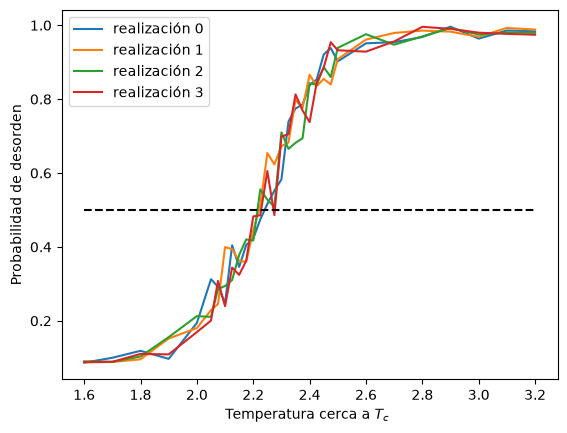

In [90]:
# --- Ejercicio 4 ---

df = pd.DataFrame( {"T":T_tc , "realizacion": realizacion_tc, "prob":p1_tc} )
resumen = df.groupby( ["realizacion", "T"] ).agg( prob_media=("prob", "mean") , prob_std=( "prob", "std"), N=("prob", "size") )# mean, std, size son los nombres de la función estadística que pandas debe aplicar en esa columna
resumen = resumen.reset_index()
resumen
 

# Realizar el grafico por realización
realizaciones_unicas = resumen["realizacion"].unique()
for i in range(len(realizaciones_unicas)):
    r = realizaciones_unicas[i] # r = 0,1,2,3
    filtro = resumen[resumen["realizacion"] == r] # Se extraen (filtra) solo las filas que tienen realización 0, 1, 2, 3
    plt.plot(filtro["T"], filtro["prob_media"], label = f"realización {i}")
    plt.xlabel("Temperatura cerca a $T_c$ ")
    plt.ylabel("Probabilidad de desorden")
    plt.legend()
    
plt.hlines(0.5,filtro["T"].min(), filtro["T"].max(), color = "black", linestyles='dashed')


Se observa que las 4 curvas (realizaciones) son bastante consistentes entre sí y no están dispersas al azar, sino que siguen  la misma forma de la curva de probabilidad y cruzan la línea (P=0.5) casi en el mismo lugar, alrededor de T≈2.25-2.30. Esto indica que la estimación de $T_c$ no depende de qué cadena de Monte Carlo se usa.

### Ejercicio 5 — Estimar $T_c$ por interpolación

Para cada realización, encuentra el primer par de temperaturas consecutivas donde
$\langle P\rangle$ cruza 0.5 e interpola linealmente:

$$T_c \approx T_i + (0.5 - P_i)\,\frac{T_{i+1}-T_i}{P_{i+1}-P_i}.$$

Luego promedia entre realizaciones y reporta la media, la desviación estándar y el error
estándar de la media (SEM).

In [ ]:
# --- Ejercicio 5  ---
def cruce_05(temps, probs):
    temps, probs = np.asarray(temps), np.asarray(probs)
    for i in range(len(temps) - 1):
        if (probs[i] - 0.5) * (probs[i + 1] - 0.5) <= 0 and probs[i + 1] != probs[i]: # Condición para saber si dos puntos consecutivos atrapa el cruce en 0.5 entre ellos.
            return (temps[i] + (0.5 - probs[i]) *
                    (temps[i + 1] - temps[i]) / (probs[i + 1] - probs[i]))
    return np.nan

#calcula el valor de Tc estimado por separado para cada una de las 4 realizaciones
Tc_por_realizacion = []
for r in np.unique(realizacion_tc):
    d = resumen[resumen.realizacion == r].sort_values("T")
    Tc_r = cruce_05(d["T"].to_numpy(), d["prob_media"].to_numpy())
    Tc_por_realizacion.append(Tc_r)
    print(f"realización {r}:  Tc = {Tc_r:.4f}")

Tc_por_realizacion = np.array(Tc_por_realizacion)
Tc_est = np.nanmean(Tc_por_realizacion)
Tc_std = np.nanstd(Tc_por_realizacion, ddof=1)
Tc_sem = Tc_std / np.sqrt(np.sum(~np.isnan(Tc_por_realizacion)))

print("\n" + "-" * 44)
print(f"Tc estimado    = {Tc_est:.4f} +/- {Tc_sem:.4f} (SEM)")
print(f"Tc Onsager     = {Tc_exacto:.4f}")
print(f"error relativo = {100 * abs(Tc_est - Tc_exacto) / Tc_exacto:.2f} %")
#print(Tc_std)

realización 0:  Tc = 2.2403
realización 1:  Tc = 2.2204
realización 2:  Tc = 2.2149
realización 3:  Tc = 2.2280

--------------------------------------------
Tc estimado    = 2.2259 +/- 0.0055 (SEM)
Tc Onsager     = 2.2692
error relativo = 1.91 %
0.01099055980929642


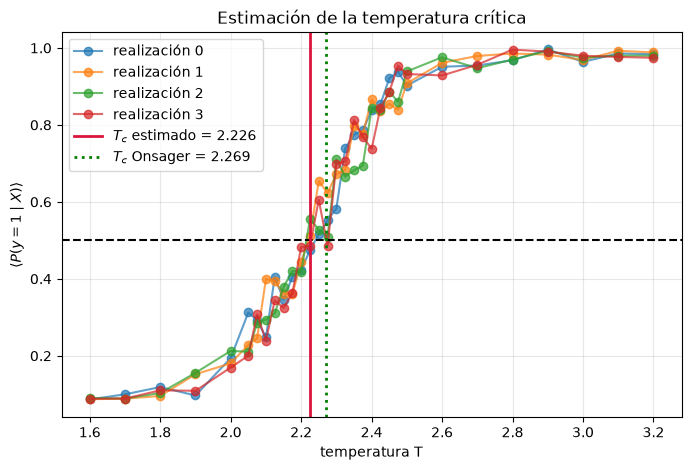

In [92]:
plt.figure(figsize=(8, 5))
for r in np.unique(realizacion_tc):
    d = resumen[resumen.realizacion == r].sort_values("T")
    plt.plot(d["T"], d["prob_media"], "o-", alpha=0.7, label=f"realización {r}")
plt.axhline(0.5, ls="--", color="k")
plt.axvline(Tc_est, ls="-", color="crimson", lw=2,
            label=fr"$T_c$ estimado = {Tc_est:.3f}")
plt.axvline(Tc_exacto, ls=":", color="green", lw=2,
            label=fr"$T_c$ Onsager = {Tc_exacto:.3f}")
plt.xlabel("temperatura T")
plt.ylabel(r"$\langle P(y=1\mid X)\rangle$")
plt.title("Estimación de la temperatura crítica")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Análisis crítico

Responde en celdas de texto, con evidencia (números o gráficas de tu notebook):

1. **Sesgo del estimador.** El $T_c$ estimado suele quedar *por debajo* de Onsager
   ($\approx 2.23$ vs $2.269$). Menciona al menos dos causas: tamaño finito $L=16$, definición
   de la etiqueta `y`, rango de temperaturas de entrenamiento, uso del umbral fijo 0.5.
2. **Arquitectura.** Repite el pipeline con `hidden_layer_sizes=(64,)` y con `(32, 16, 8)`.
   ¿Cambia $T_c$? ¿Cambia la *pendiente* de la curva en la transición?
3. **Reproducibilidad.** Entrena con 5 semillas distintas (`random_state`) y reporta
   $T_c$ media ± desviación. ¿La dispersión por semilla es mayor o menor que la dispersión
   entre realizaciones?
4. **Definición alternativa.** Usa la *fracción de configuraciones clasificadas como fase 1*
   (`pred.mean()` por $T$) en vez de `prob_media`. ¿Obtienes el mismo $T_c$?
5. **Estandarización.** Los espines ya están en $\{-1,+1\}$. ¿Ayuda un `StandardScaler`?
   ¿Por qué sí o por qué no en este problema?

## Respuestas
1. Posibles causas:
    1. El valor teórico de la temperatura crítica sólo es válido cuando se trabaja en el límite termodinámico, es decir, cuando la red es infinita. Esta temperatura crítica puede estimarse como:

    $$T_{c}(L)\sim T_{c}(\infty )+ A\cdot L^{-\frac{1}{\nu}}$$

    donde $A$ es una constante positiva o negativa. Su signo depende de como los espines del bornde se concetan con los del borde opuesto. Esta constante es negativa cuando hay un tamaño finito que limita el crecimiento de los cúmulos de espines alineados, haciendo que el orden ferromagnético sea mas inestable frente al desorden térmico. En el modelo 2D $\nu = 1$.

    En este orden de ideas, tiene sentido que la temperatura estimada esté por debajo de la teórica.

    2. El modelo se entrenó usando como clase "desordenada" (y=1) las configuraciones con T≥2.6 , la cual aunque es una temperatura  por encima de $T_c$, está relativamente cerca de la región crítica. Esto se evidencia en el histograma de magnetización, en donde la clase ordenada (y=0) se concentra aproximadamente en 1, miestras que la desordenada (y=1) presenta una amplia distribución. Esto indica que muchas de las configuraciones usadas para entrenar la etiqueta "desordenada" posiblemente no correspondían a un desorden completo, si no a un orden residual. A partir de esta tendencia, el modelo logró decirdir cuando un sistema es desordenada antes de tiempo, es decir, a temperaturas menores de las que correspondería un desorden vardaderamente completo. Por eso el sesgo se desplaza hacia valores menores de la temperatura teórica. El modelo se volvió más permisivo para etiquetar algo como desordenado.
	​

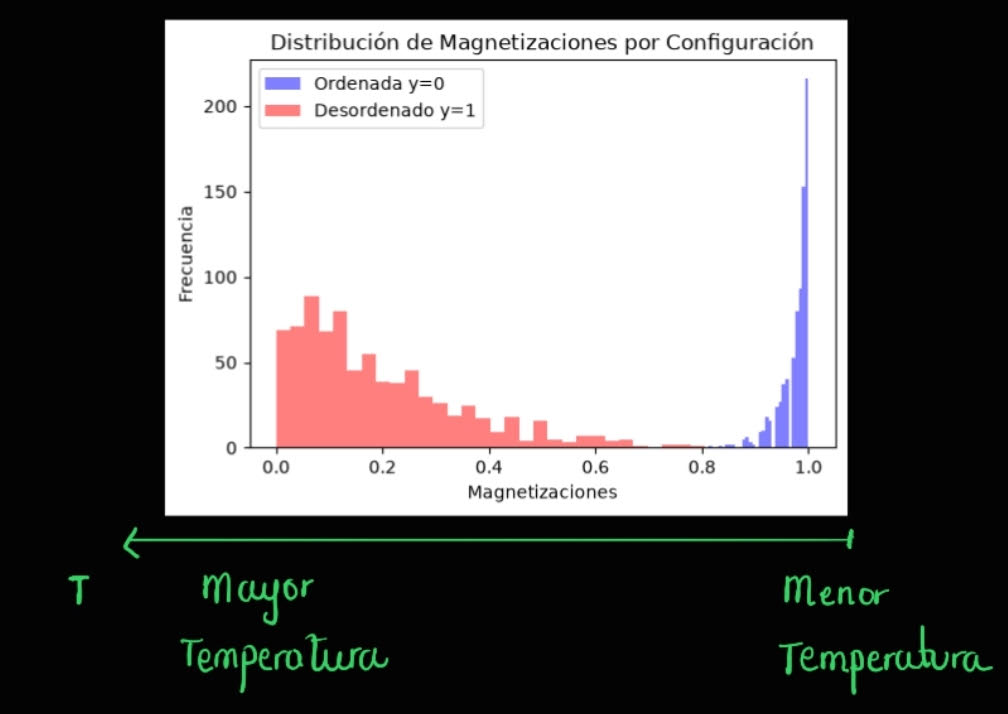

**2. Arquitectura.** Repite el pipeline con `hidden_layer_sizes=(64,)` y con `(32, 16, 8)`.
   ¿Cambia $T_c$? ¿Cambia la *pendiente* de la curva en la transición? 

In [94]:
# Modelo con una sola capa oculta con 64 neuronas.
model_1 = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=RNG,
)
# Modelo con 3 capas ocultas con 32, 16 y 18 neuronas respectivamente.
model_3 = MLPClassifier(
    hidden_layer_sizes=(32, 16, 8),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=RNG,
)

model_1.fit(X_train, y_train)
model_3.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(32, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [98]:
# Con el modelo de 1 capa:
# Probabilidad de la clase "desordenada" (y = 1)
idx1_1 = list(model_1.classes_).index(1) 
p1_tc_1 = model_1.predict_proba(X_tc)[:, idx1_1] # Vector de probabilidades que representan el estado desordenado 

# Con el modelo de 3 capas:
# Probabilidad de la clase "desordenada" (y = 1)
idx1_3 = list(model_3.classes_).index(1) 
p1_tc_3 = model_3.predict_proba(X_tc)[:, idx1_3] # Vector de probabilidades que representan el estado desordenado 



# Chequeo con y_ref 
pred_tc_1 = (p1_tc_1 >= 0.5).astype(int) # Compara cada una de las probabilidades con 0.5 devuelve un arreglo de 6200 valores True (>= 0.5)-False (< 0.5). Luego los vuelve 1 y 0
pred_tc_3 = (p1_tc_3 >= 0.5).astype(int)
print("accuracy vs y_ref (solo verificacion modelo de 1 capa):",round((pred_tc_1 == y_ref_tc).mean(), 4))
print("accuracy vs y_ref (solo verificacion modelo de 3 capas):",round((pred_tc_3 == y_ref_tc).mean(), 4))


accuracy vs y_ref (solo verificacion modelo de 1 capa): 0.8095
accuracy vs y_ref (solo verificacion modelo de 3 capas): 0.8118


Es decir, de las 6200 configuraciones del barrido fino, la decisión final del:
- Modelo con 1 capa, coincidió con la etiqueta de referencia y_ref, en el 80.95% de los casos.
- Modelo con 3 capas, coincidió con la etiqueta de referencia y_ref, en el 81.18% de los casos.

In [116]:
df_1 = pd.DataFrame( {"T":T_tc , "realizacion": realizacion_tc, "prob":p1_tc_1} )
df_3 = pd.DataFrame( {"T":T_tc , "realizacion": realizacion_tc, "prob":p1_tc_3} )

resumen_1 = df_1.groupby( ["realizacion", "T"] ).agg( prob_media=("prob", "mean") , prob_std=( "prob", "std"), N=("prob", "size") )# mean, std, size son los nombres de la función estadística que pandas debe aplicar en esa columna
resumen_3 = df_3.groupby( ["realizacion", "T"] ).agg( prob_media=("prob", "mean") , prob_std=( "prob", "std"), N=("prob", "size") )

resumen_1 = resumen_1.reset_index() # Tabla con con una fila por cada combinación única de (realizacion, T)
resumen_3 = resumen_3.reset_index()
#resumen_1
 

# calcula el Tc estimado por separado para cada una de las 4 realizaciones en modelo con 1 capa
Tc_por_realizacion_1 = []
for r in np.unique(realizacion_tc):
    d = resumen_1[resumen_1.realizacion == r].sort_values("T")
    Tc_r = cruce_05(d["T"].to_numpy(), d["prob_media"].to_numpy())
    Tc_por_realizacion_1.append(Tc_r)
    #print(f"[1 capa] realización {r}: Tc = {Tc_r:.4f}")
    
# calcula el Tc estimado por separado para cada una de las 4 realizaciones en modelo con 3 capas
Tc_por_realizacion_3 = []
for r in np.unique(realizacion_tc):
    d = resumen_3[resumen_3.realizacion == r].sort_values("T")
    Tc_r = cruce_05(d["T"].to_numpy(), d["prob_media"].to_numpy())
    Tc_por_realizacion_3.append(Tc_r)
    #print(f"[3 capas] realización {r}: Tc = {Tc_r:.4f}")
       
# -->   
#[1 capa] realización 0: Tc = 2.3616
#[1 capa] realización 1: Tc = 2.3443
#[1 capa] realización 2: Tc = 2.3832
#[1 capa] realización 3: Tc = 2.4052
#[3 capas] realización 0: Tc = 2.3667
#[3 capas] realización 1: Tc = 2.3487
#[3 capas] realización 2: Tc = 2.3808
#[3 capas] realización 3: Tc = 2.3644
    
# Promediar cada una de las Tc en cada modelo
Tc_est_1 = np.nanmean(Tc_por_realizacion_1) 
Tc_std_1 = np.nanstd(Tc_por_realizacion_1, ddof=1) # Desviación estándar
Tc_sem_1 = Tc_std_1 / np.sqrt(np.sum(~np.isnan(Tc_por_realizacion_1))) # Error estándar de la media


Tc_est_3 = np.nanmean(Tc_por_realizacion_3)
Tc_std_3 = np.nanstd(Tc_por_realizacion_3, ddof=1)
Tc_sem_3 = Tc_std_3 / np.sqrt(np.sum(~np.isnan(Tc_por_realizacion_3)))

# Iprimir los valores obtenidos

print(f"Tc estimado por modelo con 1 capa    = {Tc_est_1:.4f} +/- {Tc_sem_1:.4f} ")
print(f"Tc estimado por modelo con 3 capas    = {Tc_est_3:.4f} +/- {Tc_sem_3:.4f} ")

Tc estimado por modelo con 1 capa    = 2.3736 +/- 0.0132 
Tc estimado por modelo con 3 capas    = 2.3652 +/- 0.0066 


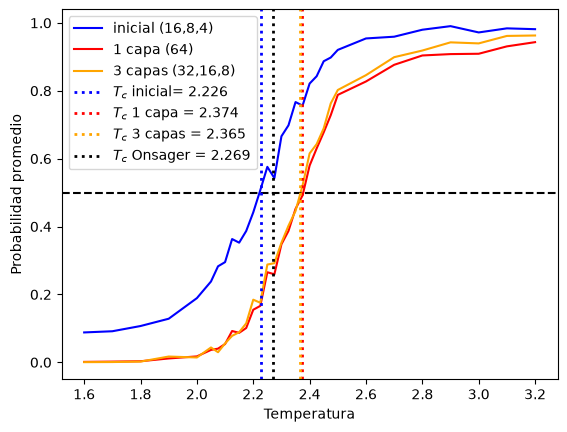

In [124]:
curva_original = resumen.groupby("T")["prob_media"].mean()
curva_1 = resumen_1.groupby("T")["prob_media"].mean() # Coge los datos de una misma temperatura, y realiza un promedio sobre los valores promedio que cada dato tiene
curva_3 = resumen_3.groupby("T")["prob_media"].mean()

plt.plot(curva_original.index, curva_original.values, label="inicial (16,8,4)", color ="blue")
plt.plot(curva_1.index, curva_1.values, label="1 capa (64)", color ="red")
plt.plot(curva_3.index, curva_3.values, label="3 capas (32,16,8)", color ="orange")
plt.axhline(0.5, ls="--", color="black")

plt.axvline(Tc_est, ls=":", color="blue", lw=2, label=fr"$T_c$ inicial= {Tc_est:.3f}")
plt.axvline(Tc_est_1, ls=":", color="red", lw=2, label=fr"$T_c$ 1 capa = {Tc_est_1:.3f}")
plt.axvline(Tc_est_3, ls=":", color="orange", lw=2, label=fr"$T_c$ 3 capas = {Tc_est_3:.3f}")
plt.axvline(Tc_exacto, ls=":", color="black", lw=2, label=fr"$T_c$ Onsager = {Tc_exacto:.3f}")
plt.xlabel("Temperatura")
plt.ylabel("Probabilidad promedio")
plt.legend()
plt.show()



Se observa enotnces que la arquitectura inicial, compuesta por (16, 8,4) tiene mejor resultado en comparación con las arquitecturas con menor número de capas.

Se observa que la pendiente cambia. Por un lado, en el modelo original (16,8,4) hay una transición gradual, extendida en un rango  de temperaturas (aproximadamente de T≈1.9 a T≈2.9).Por otro lado, los modelos con 1 (64) y 3 capas (32,16,8) muestran una  transición mucho más empinada, aproximadamente T≈2.3 a T≈2.5

**3. Reproducibilidad.** Entrena con 5 semillas distintas (`random_state`) y reporta
   $T_c$ media ± desviación. ¿La dispersión por semilla es mayor o menor que la dispersión
   entre realizaciones?

In [125]:
def calcular_tc(seed, hidden_layer_sizes=(16, 8, 4)):
    modelo = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, activation="relu",
                            solver="adam", learning_rate_init=0.001, max_iter=1000,
                            random_state=seed)
    modelo.fit(X_train, y_train)
    idx1 = list(modelo.classes_).index(1)
    p1 = modelo.predict_proba(X_tc)[:, idx1]

    df_tmp = pd.DataFrame({"T": T_tc, "realizacion": realizacion_tc, "prob": p1})
    resumen_tmp = (df_tmp.groupby(["realizacion", "T"])
                         .agg(prob_media=("prob", "mean")).reset_index())

    tcs = []
    for r in np.unique(realizacion_tc):
        d = resumen_tmp[resumen_tmp.realizacion == r].sort_values("T")
        tcs.append(cruce_05(d["T"].to_numpy(), d["prob_media"].to_numpy()))
    return np.nanmean(tcs)

In [134]:
semillas = [42, 0, 1, 2, 3]
Tc_por_semilla = [calcular_tc(s) for s in semillas]

Tc_media_semillas = np.mean(Tc_por_semilla)
Tc_std_semillas = np.std(Tc_por_semilla, ddof=1)

print(f"Tc por semilla: {np.round(Tc_por_semilla,4)}")
print(f"Media ± std entre semillas: {Tc_media_semillas:.4f} ± {Tc_std_semillas:.4f}")
print(f"Dispersión por realización: {Tc_std}")
print(f"Dispersión por semillas: {Tc_std_semillas}")

Tc por semilla: [2.2259 2.3578 2.3633 2.3619 2.2767]
Media ± std entre semillas: 2.3171 ± 0.0627
Dispersión por realización: 0.01099055980929642
Dispersión por semillas: 0.0627439225130035


Significa que la variablidad en el valor estimado de $T_c$ viene dada en mayor parte por la aleatoriedad del entrenamiento de la red neuronal. Con distintas iniciaciones de pesos, el modelo puede terminar aprendiendo fronteras de desición diferentes.

Se observa entonces que la semilla 42, da el mismo resultado estimado de $T_c = 2.226$ anteriormente.

Además, se encuentra que la semilla = 3 presenta un mejor valor aproximado a la temperatura exacta.

In [145]:
diferencias = [abs(Tc_exacto - i) for i in Tc_por_semilla]
print(f"Diferencia entre valor de Tc de cada semilla con respecto al valor exacto: {np.round(diferencias, 4)}")

Diferencia entre valor de Tc de cada semilla con respecto al valor exacto: [0.0433 0.0886 0.0941 0.0927 0.0075]


4. **Definición alternativa.** Usa la *fracción de configuraciones clasificadas como fase 1*
   (`pred.mean()` por $T$) en vez de `prob_media`. ¿Obtienes el mismo $T_c$?

In [153]:
pred = (p1_tc >= 0.5).astype(int) # Compara cada una de las probabilidades con 0.5 devuelve un arreglo de 6200 valores True (>= 0.5)-False (< 0.5). Luego los vuelve 1 y 0

df_pred = pd.DataFrame( {"T":T_tc , "realizacion": realizacion_tc, "pred":pred} )
resumen_pred = df_pred.groupby( ["realizacion", "T"] ).agg( pred_media = ("pred", "mean") , prob_std=( "pred", "std"), N=("pred", "size") )# mean, std, size son los nombres de la función estadística que pandas debe aplicar en esa columna
resumen_pred = resumen_pred.reset_index()

# Para cada realización, encontrar el cruce de 0.5 
Tc_por_realizacion_pred = []
for r in np.unique(realizacion_tc):
    d = resumen_pred[resumen_pred.realizacion == r].sort_values("T")
    Tc_r = cruce_05(d["T"].to_numpy(), d["pred_media"].to_numpy())
    Tc_por_realizacion_pred.append(Tc_r)
    
    
# Promediar entre realizaciones
Tc_est_pred = np.nanmean(Tc_por_realizacion_pred)
print(f"Tc con pred_media = {Tc_est_pred:.4f}")
print(f"Comparación entre pred_media y prob_media {abs(Tc_est_pred - Tc_est)} ")

Tc con pred_media = 2.2331
Comparación entre pred_media y prob_media 0.007213437446099924 


No hay una diferencia signbificativa entre ambos valores calculados, lo que significa que no importa si se usa el 
promedio de las probabilidades continuas (que conserva qué tan confiado está el modelo en cada predicción) o la fracción de configuraciones clasificadas como fase 1 (que solo cuenta decisiones binarias), ambas formas muestran la misma transición.

5. **Estandarización.** Los espines ya están en $\{-1,+1\}$. ¿Ayuda un `StandardScaler`?
   ¿Por qué sí o por qué no en este problema?

In [ ]:
from sklearn.preprocessing import StandardScaler

# 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Calcular la media y la desviación estándar de cada una de las 256 columnas de X_train
X_tc_scaled = scaler.transform(X_tc)  # Reescala X_tc usando la media y desviación estándar que YA fueron calculadas con X_train (no calcula nuevas estadísticas a partir de X_tc)


model_scaled = MLPClassifier(hidden_layer_sizes=(16, 8, 4), activation="relu",
                              solver="adam", learning_rate_init=0.001,
                              max_iter=1000, random_state=RNG)
model_scaled.fit(X_train_scaled, y_train)

idx1_s = list(model_scaled.classes_).index(1)
p1_tc_scaled = model_scaled.predict_proba(X_tc_scaled)[:, idx1_s]

df_s = pd.DataFrame({"T": T_tc, "realizacion": realizacion_tc, "prob": p1_tc_scaled})
resumen_s = (df_s.groupby(["realizacion", "T"])
                 .agg(prob_media=("prob", "mean")).reset_index())

Tc_por_realizacion_s = []
for r in np.unique(realizacion_tc):
    d = resumen_s[resumen_s.realizacion == r].sort_values("T")
    Tc_por_realizacion_s.append(cruce_05(d["T"].to_numpy(), d["prob_media"].to_numpy()))

Tc_est_scaled = np.nanmean(Tc_por_realizacion_s)
print(f"Tc sin escalar        = 2.2259")
print(f"Tc con StandardScaler = {Tc_est_scaled:.4f}")

Tc sin escalar        = 2.2259
Tc con StandardScaler = 2.2076


Se observa entonces que el uso de StandardScaler no mejora el valor de la temperatura estimada.
StandardScaler se usa para reescalar las características de un conjunto de datos, de modo que cada una tenga media 0 y desviación estándar 1. Esto sería útil cuando distintas columnas tienen escalas diferentes entre sí ya que ayuda a que el entrenamiento de un modelo converja mejor.

En este caso, todas los 256 espines ya comparten la misma escala (±1), por lo que no existe el problema de escalas heterogéneas que StandardScaler normalmente resuelve. Además, el promedio que calcula por cada espín depende de hacia qué lado
(+1 o -1) se inclinó la simulación de Monte Carlo usada para entrenar, lo cual no necesariamente coincide con la inclinación de otras simulaciones independientes (como las del barrido fino), por lo que además empeora ligeramente la estimación de Tc.

## 9. Reto  — Escalamiento con el tamaño del sistema

Con el programa de ising generar varias datos para diferentes tipo de redes L=10x10, L=15x15, L=20x20, L=25x25, L=30x30

1. Construye un conjunto de entrenamiento.
2. Entrena un nuevo `MLPClassifier`, repite los Ejercicios 4–5 y obtén $T_c(L=20)$.
3. Compara todas las $T_c$ ¿La estimación se acerca a Onsager al crecer $L$?
   Relaciónalo con el *finite-size scaling*.

In [156]:
# Del archivo Sesion07_bDatos_Ising.ipynb
import numpy as np

TC_ONSAGER = 2.0 / np.log(1.0 + np.sqrt(2.0))   # ~2.269185, temperatura critica de Onsager


class IsingMetropolis:
    """Dinamica de Metropolis (vectorizada por tablero de ajedrez) para el Ising 2D."""

    def __init__(self, L, T, frontera='periodica', espines=None, J=1.0, semilla=None):
        if frontera not in ('periodica', 'libre'):
            raise ValueError("frontera debe ser 'periodica' o 'libre'")
        self.L = int(L)
        self.N = self.L * self.L
        self.frontera = frontera
        self.J = float(J)
        self.rng = np.random.default_rng(semilla)
        self.T = T

        if espines is None:
            self.s = self.rng.choice(np.array([-1, 1], dtype=np.int8), size=(self.L, self.L))
        else:
            self.s = np.asarray(espines, dtype=np.int8).reshape(self.L, self.L).copy()

        i, j = np.indices((self.L, self.L))
        self.sub_A = ((i + j) % 2 == 0)
        self.sub_B = ~self.sub_A

    @property
    def T(self):
        return self._T

    @T.setter
    def T(self, valor):
        self._T = float(valor)
        self.beta = 1.0 / self._T

    def _suma_vecinos(self):
        s = self.s
        if self.frontera == 'periodica':
            return (np.roll(s, 1, 0) + np.roll(s, -1, 0)
                    + np.roll(s, 1, 1) + np.roll(s, -1, 1))
        arriba = np.zeros_like(s); arriba[1:, :] = s[:-1, :]
        abajo = np.zeros_like(s);  abajo[:-1, :] = s[1:, :]
        izq = np.zeros_like(s);    izq[:, 1:] = s[:, :-1]
        der = np.zeros_like(s);    der[:, :-1] = s[:, 1:]
        return arriba + abajo + izq + der

    def barrido(self):
        for subred in (self.sub_A, self.sub_B):
            vecinos = self._suma_vecinos()
            dE = 2.0 * self.J * self.s * vecinos
            prob = np.exp(-self.beta * np.clip(dE, 0.0, None))
            voltea = (self.rng.random(self.s.shape) < prob) & subred
            self.s[voltea] = -self.s[voltea]

    def termalizar(self, n_barridos):
        for _ in range(int(n_barridos)):
            self.barrido()

    def energia(self):
        s = self.s.astype(np.int64)
        if self.frontera == 'periodica':
            pares = s * (np.roll(s, -1, 0) + np.roll(s, -1, 1))
            return -self.J * float(pares.sum())
        pares = (s[:-1, :] * s[1:, :]).sum() + (s[:, :-1] * s[:, 1:]).sum()
        return -self.J * float(pares)

    def magnetizacion(self):
        return int(self.s.sum(dtype=np.int64))

    def configuracion(self):
        return self.s.copy()


def generar_dataset_ising(L, temperaturas, n_config_por_T, n_realizaciones=1,
                          frontera='periodica', J=1.0, n_termalizacion=2000,
                          barridos_entre_config=25, margen=0.15, simetrizar=True,
                          semilla=0, verbose=True):
    """Genera configuraciones de Ising etiquetadas por fase (recocido de T alta a baja)."""
    temperaturas = np.sort(np.asarray(temperaturas, dtype=float))[::-1]
    Tc = 2.0 / np.log(1.0 + np.sqrt(2.0))

    ss = np.random.SeedSequence(semilla)
    sim_rng = np.random.default_rng(ss.spawn(1)[0])
    semillas_cadenas = ss.spawn(n_realizaciones)

    X, T_lista, y_lista, m_lista, r_lista = [], [], [], [], []
    for r, sem in enumerate(semillas_cadenas):
        mc = IsingMetropolis(L, T=temperaturas[0], frontera=frontera, J=J, semilla=sem)
        for Temp in temperaturas:
            mc.T = Temp
            mc.termalizar(n_termalizacion)
            if abs(Temp - Tc) < margen:
                continue
            for _ in range(int(n_config_por_T)):
                mc.termalizar(barridos_entre_config)
                conf = mc.configuracion()
                if simetrizar and sim_rng.random() < 0.5:
                    conf = (-conf).astype(np.int8)
                X.append(conf)
                T_lista.append(Temp)
                y_lista.append(0 if Temp < Tc else 1)
                m_lista.append(abs(int(conf.sum(dtype=np.int64))) / mc.N)
                r_lista.append(r)
        if verbose:
            n_T_validas = int((np.abs(temperaturas - Tc) >= margen).sum())
            print(f"realizacion {r + 1}/{n_realizaciones}: "
                  f"{n_T_validas} temperaturas x {n_config_por_T} configs")

    return (np.asarray(X, dtype=np.int8),
            np.asarray(T_lista, dtype=float),
            np.asarray(y_lista, dtype=np.int8),
            np.asarray(m_lista, dtype=float),
            np.asarray(r_lista, dtype=np.int16))
    
    
# Temperaturas para el dataset de entrenamiento (evitan la banda crítica)
temps_dataset = np.concatenate([
    np.linspace(3.50, 2.60, 5),    # T > T_c  -> fase desordenada  (y = 1)
    np.linspace(1.90, 1.20, 5),    # T < T_c  -> fase ordenada     (y = 0)
])

# Temperaturas para el barrido fino (estimar Tc por cruce de probabilidad)
temps_criticas = np.unique(np.concatenate([
    np.linspace(1.60, 2.00, 5),     # meseta ordenada
    np.linspace(2.05, 2.50, 19),    # zona critica, rejilla fina (paso ~0.025)
    np.linspace(2.60, 3.20, 7),     # meseta desordenada
]))

In [157]:
Ls = [10, 15, 20, 25, 30] # Tamaños de la red de espines
resultados_L = {}         # Diccionario para guardar los datos. Cada clave(tamaño red):valor(Tc)

for L in Ls:
    print(f"--- L = {L} ---")

    # 1. Generar los datos con los mismos parámetros que L=16
    X, T_muestra, y, m_muestra, realizacion = generar_dataset_ising(
        L=L, temperaturas=temps_dataset, n_config_por_T=40, n_realizaciones=4,
        frontera='periodica', n_termalizacion=1500, barridos_entre_config=20,
        margen=0.0, simetrizar=True, semilla=1, verbose=False,
    )

    # 2. Generar los datos con los mismos parámetros que L=16 para barrido fino
    X_tc, T_tc, y_ref_tc, m_tc, r_tc = generar_dataset_ising(
        L=L, temperaturas=temps_criticas, n_config_por_T=50, n_realizaciones=4,
        frontera='periodica', n_termalizacion=1500, barridos_entre_config=15,
        margen=0.0, simetrizar=True, semilla=7, verbose=False,
    )
    
    # 3. Entrenar el modelo con la misma arquitectura del Ejercicio 4. No se distingue entre datos train y test. Solo se entrena el modelo con X_flat y y los X_tc serán los de prueba
    X_flat = aplanar(X)
    X_tc_flat = aplanar(X_tc)

    model = MLPClassifier(
        hidden_layer_sizes=(16, 8, 4),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=RNG,
    )
    
    model.fit(X_flat, y)

    # 4. Predecir en el barrido fino y estimar Tc
    prob = model.predict_proba(X_tc_flat)[:, 1]  # Le pide al modelo, para cada configuración del barrido fino, la probabilidad de pertenecer a cada clase. Devuelve un array de forma (N, 2): columna 0 = probabilidad de "ordenada" (y=0), columna 1 = probabilidad de "desordenada" (y=1)

    df_L = pd.DataFrame({"T": T_tc, "prob": prob})
    resumen_L = df_L.groupby("T")["prob"].mean().reset_index() # Agrupa todas las filas que comparten la misma temperatura y promedia su prob. Calcula P(y=1|X) para cada T
    Tc_L = cruce_05(resumen_L["T"].to_numpy(), resumen_L["prob"].to_numpy()) #Interpolando linealmente entre los dos puntos más cercanos al cruce

    resultados_L[L] = Tc_L
    print(f"Tc estimado (L={L}) = {Tc_L:.4f}")

--- L = 10 ---
Tc estimado (L=10) = 2.3103
--- L = 15 ---
Tc estimado (L=15) = nan
--- L = 20 ---
Tc estimado (L=20) = 2.3148
--- L = 25 ---
Tc estimado (L=25) = 2.8711
--- L = 30 ---
Tc estimado (L=30) = 2.3171


Se observa que los valores de una red par $L= 10, 20, 30$ dan valores bastante asertados al valor de la Tempreatura.

El algoritmo de Metropolis vectorizado actualiza la red por "tablero de ajedrez": divide los sitios en dos subredes según la paridad de i+j y voltea primero todos los de una subred y luego los de la otra, asumiendo que ningún sitio es vecino de otro de su misma subred. Esa suposición se cumple siempre en una red abierta, pero con frontera periódica y L impar se rompe en el empate donde la red se enrolla sobre sí misma. Esto hace que, para L impar, algunos sitios vecinos se actualicen simultáneamente usando información desactualizada el uno del otro. Lejos de este sesgo es poco perceptible, pero cerca de la temperatura crítica donde el sistema es menos seguro se amplifica lo suficiente como para distorsionar la curva de probabilidad y que la estimación de por cruce falle.

In [162]:
resultados_validos = {}
excluidos = []

for L in resultados_L:
    Tc_L = resultados_L[L]
    if L % 2 == 0:
        resultados_validos[L] = Tc_L
    else:
        excluidos.append(L)

print("L", "Tc estimado", "Tc - Onsager:")
for L in resultados_validos:
    Tc_L = resultados_validos[L]
    diferencia = Tc_L - TC_ONSAGER
    print(L, Tc_L, diferencia)

print("Excluidos por sesgo de L impar (frontera periodica):", excluidos)
print(resultados_validos)

L Tc estimado Tc - Onsager:
10 2.3103223402934385 0.04113702608041647
20 2.3147676288709746 0.045582314657952594
30 2.3170534581788096 0.047868143965787535
Excluidos por sesgo de L impar (frontera periodica): [15, 25]
{10: np.float64(2.3103223402934385), 20: np.float64(2.3147676288709746), 30: np.float64(2.3170534581788096)}


Según la teoría de finite-size scaling, la relación que predice $T_c(L)$ 
 $$T_{c}(L)\sim T_{c}(\infty )+ A\cdot L^{-\frac{1}{\nu}}$$

Con $\nu =1$:
$$T_{c}(L)\sim T_{c}(\infty )+\frac{A}{L}$$


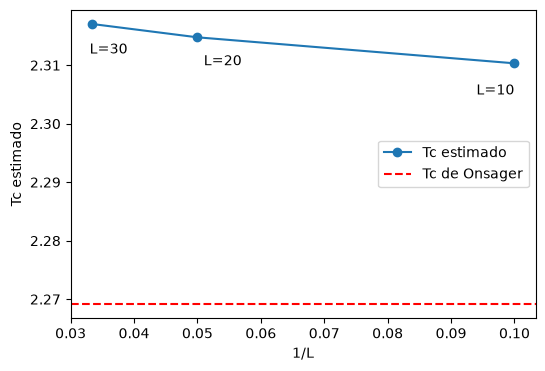

In [184]:
Ls_validos = []
Tc_validos = []

for L in sorted(resultados_validos):
    Ls_validos.append(L)
    Tc_validos.append(resultados_validos[L])
    
Ls_validos = np.array(Ls_validos, dtype=float)
Tc_validos = np.array(Tc_validos)


plt.figure(figsize=(6,4))
plt.plot(1/Ls_validos, Tc_validos, 'o-', label='Tc estimado')
plt.axhline(TC_ONSAGER, color='r', linestyle='--', label='Tc de Onsager')
plt.xlabel('1/L')
plt.ylabel('Tc estimado')
plt.text(0.033, 2.312, "L=30")
plt.text(0.051, 2.310, "L=20")
plt.text(0.094, 2.305, "L=10")
plt.legend()
plt.show()

Al comparar la temperatura crítica estimada originalmente para $L=16$ ($T_c \approx 2.226$) con las obtenidas para los nuevos tamaños de red, se observa que $L=10$ es el que presenta la menor diferencia respecto al valor teórico de Onsager ($T_c \approx 2.269$), seguido de $L=20$ y luego $L=30$, cuyo estimado se aleja aún más del valor teórico.

Según la teoría de *finite-size scaling*, este resultado es ambiguo dado que se esperaría que $T_c(L)$ se acercara al valor teórico a medida que $L$ crece. Es probable que este comportamiento se deba a una limitación dado que se usó la misma arquitectura de red (16, 8, 4) para todos los tamaños, pero el número de características de entrada crece considerablemente con $L$ (de $10^2=100$ a $30^2=900$), lo que dificulta que el modelo aprenda una buena frontera de decisión a medida que $L$ aumenta.